# Part 1: Comparing decision trees with other models

**Advantages of decision trees:**
    
- Can be used for regression or classification
- Can be displayed graphically
- Highly interpretable
- Can be specified as a series of rules, and more closely approximate human decision-making than other models
- Prediction is fast
- Features don't need scaling
- Automatically learns feature interactions
- Tends to ignore irrelevant features
- Non-parametric (will outperform linear models if relationship between features and response is highly non-linear)
- Robust to the outliers
- Impact of Missing values is Minimal

<h4> <center> Below is the example of DT implementation on Classification Problem statement using the advistrisement dataset

In [1]:
# Decision Tree Classification

# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # data related functionalities are coming from this

# dtreeviz and graphviz | libraries to visualize the Dtree being created


#### Importing the dataset

In [2]:
# Step 1 : Importing the dataset
dataset = pd.read_csv('Advertisements.csv')
#dataset.shape
dataset.head(2)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0


#### You have to have the prper >> irrespective of Ankur Doing that or not in this case
##### Understanding - EDA
#### Cleaning
#### Preparing the data

In [3]:
# EDA ofcourse to the extent it is possible
#___________________________________________________

dataset.head(2)
#dataset.info()   # str() function in R
#dataset.columns    # names() in R
#dataset.shape       # dim() in R
#dataset.describe()   # summary() in R


# Homework
# 'pandas_profiling' # this is very interesting Package for you to get in and out of everything from the data.


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0


In [4]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
User ID,400.0,1.569154e+07,71658.321581,15566689.0,15626763.75,15694341.5,15750363.0,15815236.0
Age,400.0,3.765500e+01,10.482877,18.0,29.75,37.0,46.0,60.0
EstimatedSalary,400.0,6.974250e+04,34096.960282,15000.0,43000.00,70000.0,88000.0,150000.0
Purchased,400.0,3.575000e-01,0.479864,0.0,0.00,0.0,1.0,1.0


In [5]:
#pip install numba==0.59.1

In [6]:
pip install ydata-profiling

  Using cached ydata_profiling-4.18.4-py2.py3-none-any.whl.metadata (23 kB)
  Using cached wordcloud-1.9.6-cp313-cp313-win_amd64.whl.metadata (3.5 kB)
Using cached ydata_profiling-4.18.4-py2.py3-none-any.whl (400 kB)
Using cached wordcloud-1.9.6-cp313-cp313-win_amd64.whl (306 kB)

   -------------------- ------------------- 1/2 [ydata-profiling]
   -------------------- ------------------- 1/2 [ydata-profiling]
   -------------------- ------------------- 1/2 [ydata-profiling]
   -------------------- ------------------- 1/2 [ydata-profiling]
   -------------------- ------------------- 1/2 [ydata-profiling]
   ---------------------------------------- 2/2 [ydata-profiling]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
# Spliting the overall data into X and Y [this is what is required in ML]

X = dataset.iloc[:, [2, 3]].values # because indexing in Python starts from 0 to n-1 |
                                      # puling age and Esitmated Salary

y = dataset.iloc[:, 4].values # 'Purchased' as Y column

In [8]:
# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 1111)


In [9]:
print(X_train.shape)

(300, 2)


In [10]:
#X_train

In [11]:
# * Feature Scaling | Scaling the variables | standardizign the variable |
# Z - score | Mean = 0 and STD = 1
# To get all the variables on same scale [towards ZERO]

#Ex: Salary[123000000] and Age[22] are two columns which have vary much distant values

#___________________________________________________________________________

# In the DT, though it is not required but mandatory in KNN (classification) KMEANS (clustering) because :
                                               # these algorithms are distance based algorithm

# still a good read !!

#_______________________________________________________________________________________________________________________
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()


X_train = sc.fit_transform(X_train) # you are finding the MEan and STD{with the fit()
#                                    }on training data and aslo transforming that

X_test = sc.transform(X_test)       # Only tranforming now


In [12]:
from sklearn.tree import DecisionTreeClassifier
#DecisionTreeClassifier?

In [13]:
from sklearn.tree import DecisionTreeClassifier

In [14]:
DecisionTreeClassifier

sklearn.tree._classes.DecisionTreeClassifier

In [15]:
#DecisionTreeClassifier?

# classifier = DecisionTreeClassifier(random_state = 0) # without palying with any of the arugment's value:

from sklearn.tree import DecisionTreeClassifier

classifier = DecisionTreeClassifier(random_state = 0) # > this will have Gini Index
classifier

# all the arugments are as of now : running with the default / standard value
# In case if you think that you know in and out of Decision methodology:
     # the mahtematics behind that and the way it works behind the curtains

# if you think you are RajniKant/ JAmes Bond for this Techniqie -
# then welcome to the party to play around the values of the arguments ?
# now what ideally should be the values of those argumetns is either some one tells you ?
# or you identify !!

# HEnce for that purpose only - Hyper Parameter tuning is done

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [16]:
# sklearn - is the prime package for all the typicall ML based algorithms
#_______________________________________________________________________
# Fitting Decision Tree Classification to the Training set

from sklearn.tree import DecisionTreeClassifier

classifier = DecisionTreeClassifier(random_state = 0) # > this will have Gini Index

# classifier = DecisionTreeClassifier(criterion = 'entropy', random_state = 0) #  this will have Entropy Index




In [17]:
classifier.fit(X_train, y_train) # to train the model with X_train and y_train
#classifier
# _________________________________________________________________________________________________________________
# Rerun the model again: with the below arugments and the optimised value - Hyperparameter | gridsearch
# {'max_depth': 2, 'min_samples_leaf': 40, 'min_samples_split': 20}


# classifier = DecisionTreeClassifier(criterion = 'entropy',
                                            # random_state = 0, max_depth= 2,
                                            # 'min_samples_leaf': 40,
                                            #     'min_samples_split': 20)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

#### Which of the two is better  [ Gini / Entropy ]?
- 1. Generally speaking, either deliver fairly similar outcomes and Gini,
owing to less computational rigour gets favoured
- 2. However, Entropy(reduction)/Information Gain seems to be preferred if
the predicted variable is skewed (e.g. default in loans)
- 3. Entropy also tends to be more effective when the number of features are
large
- 4. Gini Score is used in CART while Entropy/Information Gain is used in
ID3 and C4.5
- 5. In sum, Entropy appears to be a better method to use as it can deal with
skewed dependent variables and also when one needs to go beyond
binary classification problems

In [18]:
# Predicting the Test set results
# This Prredict function : it to Apply the MODEL

y_pred = classifier.predict(X_test) # this is "Test Y predicted"

In [19]:
y_pred # predictied Y Test values of 0 or 1

array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0])

In [20]:
y_test # actual Y test Set of 0 or 1

array([0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0])

In [21]:
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

# |         | 预测说要带伞  | 预测说不要带伞 |
# | ------- | ------- | ------- |
#| 实际上应该带伞 | TP = 58 | FN = 10  |
#| 实际上不该带伞 | FP = 5  | TN = 27 |
#TP = 58%
#TN = 27%
#FN= 10%
#FP - 5%
#准确率 (Accuracy)58%+27%= 85%
#精确率 (Precision)Precision= TP/(tp+FP)=58/(58+5)=92.1%
# 召回率 (Recall / Sensitivity) = TP(TP+FN)=58/(58+10)=85.3%
#F1 分数 (F1 Score)=2⋅Precision⋅Recall/Precision+Recall=2⋅0.921x0.853/0.921+0.853=88.5%

#你的模型整体 预测正确率是 85%
#它在预测“正类”方面非常可靠（Precision 高达 92%）
#但有一些真正的正类被漏掉（Recall 是 85.3%）
#整体表现平衡、优秀，F1 分数也很高（88.5%）

 #如果你希望减少漏报（FN），可以提高 Recall；
# 如果你希望减少误报（FP），可以提高 Precision。

#______________________________________________________________________________________________
# accuracy_score | Accuracy you are gettinng below is 84 %
#______________________________________________________________________________________________
# auc_ROC  = over the test data ?

array([[58, 10],
       [ 5, 27]])

In [22]:

from sklearn import metrics

print(dir(metrics))

print('Accuracy: ',metrics.accuracy_score(y_test, y_pred))
print('AUC_ROC SCORE: ',metrics.roc_auc_score(y_test, y_pred))

['ConfusionMatrixDisplay', 'DetCurveDisplay', 'DistanceMetric', 'PrecisionRecallDisplay', 'PredictionErrorDisplay', 'RocCurveDisplay', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '_base', '_classification', '_dist_metrics', '_pairwise_distances_reduction', '_pairwise_fast', '_plot', '_ranking', '_regression', '_scorer', 'accuracy_score', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'auc', 'average_precision_score', 'balanced_accuracy_score', 'brier_score_loss', 'calinski_harabasz_score', 'check_scoring', 'class_likelihood_ratios', 'classification_report', 'cluster', 'cohen_kappa_score', 'completeness_score', 'confusion_matrix', 'confusion_matrix_at_thresholds', 'consensus_score', 'coverage_error', 'd2_absolute_error_score', 'd2_brier_score', 'd2_log_loss_score', 'd2_pinball_score', 'd2_tweedie_score', 'davies_bouldin_score', 'dcg_score', 'det_curve', 'euclidean_distances', 'explained_variance_s

C:\Users\tanma\AppData\Local\Temp\ipykernel_20524\3153103629.py:17: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


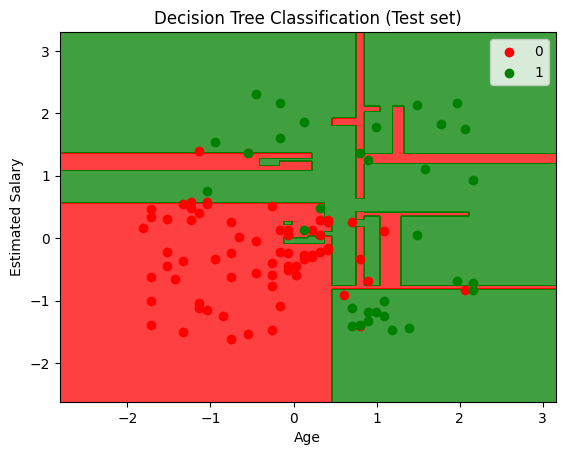

In [24]:
# Visualising the Test set results
from matplotlib.colors import ListedColormap

X_set, y_set = X_test, y_test

X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))


plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Decision Tree Classification (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

**Disadvantages of decision trees:**
    
- Performance is (generally) not competitive with the best supervised learning methods
    - Use Ensembles
- Can easily overfit the training data (tuning is required / PRUNING standard concept we talked about)

- Small variations in the data can result in a completely different tree (high variance)
    - Use Ensembles to reduce the variance
    
- Recursive binary splitting makes "locally optimal" decisions that may not result in a globally optimal tree
- Doesn't tend to work well if the classes are highly unbalanced
- Doesn't tend to work well with very small datasets

In [25]:
#### Finetune the performance of the model | hyperparameter tuning

In [26]:
from sklearn.model_selection import GridSearchCV

In [27]:
pGrid = {'max_depth': range(2, 10), # 8  - 2,3,4,5,6,7,8
        'min_samples_leaf': range(10, 51, 10),  # 5 -> 10,20,30,40,50
        'min_samples_split': range(20, 81, 20)}   # 4 -> 20,40,60,80
# number of model will run = 160 (8*5*4) iteraltion; cross validation Kfold cross;
gscv_dt = GridSearchCV(estimator = DecisionTreeClassifier(),
                       param_grid = pGrid,
                       cv = 5,  #160*5 = 800 iteralition;
                       scoring = 'accuracy',
                       n_jobs = -1,
                       verbose = True)

In [28]:
gscv_dt.fit(X, y)

gscv_dt.best_params_

Fitting 5 folds for each of 160 candidates, totalling 800 fits


{'max_depth': 2, 'min_samples_leaf': 10, 'min_samples_split': 20}

In [29]:
gscv_dt.best_params_

{'max_depth': 2, 'min_samples_leaf': 10, 'min_samples_split': 20}

In [30]:
param_grid = {'max_depth': np.arange(2, 15),
                 'max_features': np.arange(2, 4)}


tree = GridSearchCV(DecisionTreeClassifier(random_state = 1), param_grid, cv = 5, scoring = 'roc_auc')

#tree.fit(train_X, train_y)
tree.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...andom_state=1)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': array([ 2, 3..., 12, 13, 14]), 'max_features': array([2, 3])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score 

In [31]:
# Task : get the classification done on wine dataset which is preloaded and also come across with the
# visuals of DT being created


# PS : to build a DT classifier model to predict if a sample is
# picked a wine and corresponding ingredeints [ 13 ingredeints are there] from which winyeard [ 0 or 1 or 2 ? ]

Accuracy: 0.9629629629629629

Classification Report:
               precision    recall  f1-score   support

     class_0       0.95      0.95      0.95        19
     class_1       0.95      1.00      0.98        21
     class_2       1.00      0.93      0.96        14

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.96      0.96      0.96        54



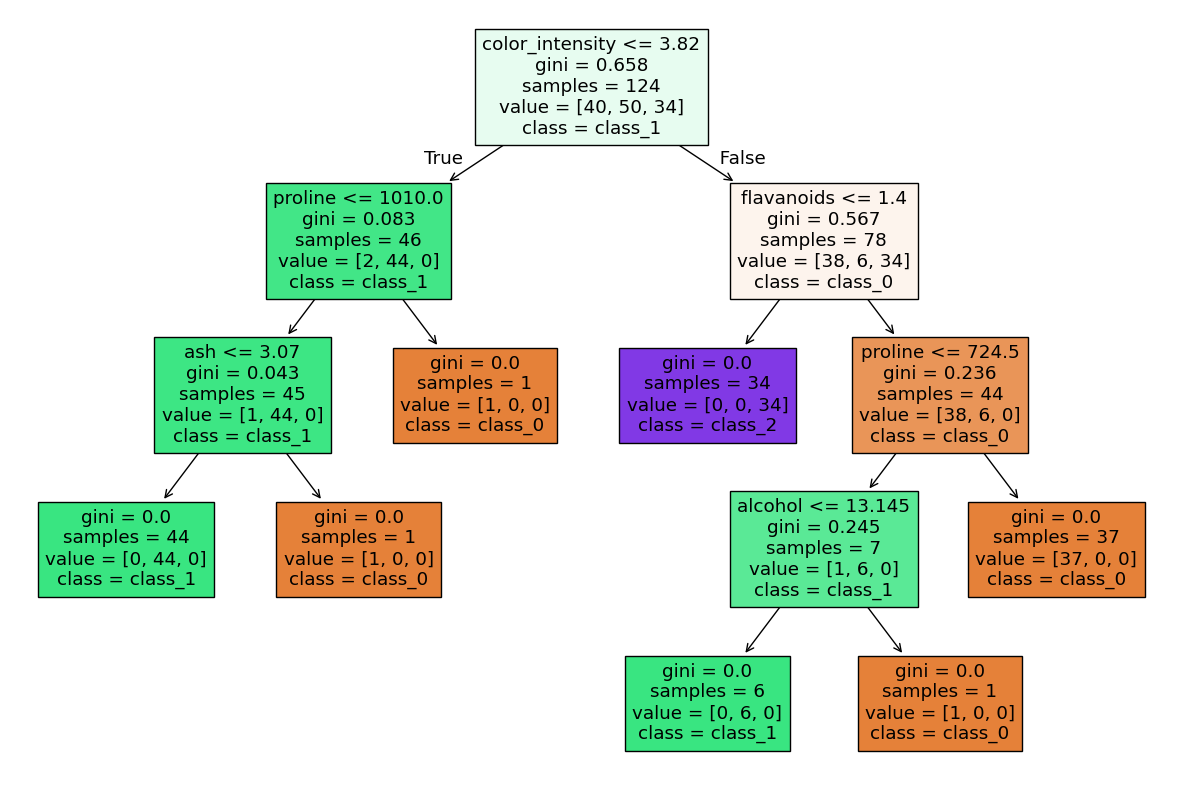

In [32]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
wine = load_wine()
X, y = wine.data, wine.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Build Decision Tree
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

# Predictions
y_pred = dt.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=wine.target_names))

# Visualize the tree
plt.figure(figsize=(15,10))
plot_tree(dt, feature_names=wine.feature_names, class_names=wine.target_names, filled=True)
plt.show()